## Author: Alfredo Bernal Luna
## Date: April 27th 2026

### This Jupyter notebook explains briefly what's the Pandas DataFrame object, how it works, and the following fundamental actions one can do with them:
1. READ/INSPECT DATA
2. SELECT SUBSETS OF DATA
3. FILTER DATA BY A BOOLEAN EXPRESSION / BY NULL VALUES
4. SORT DATA
5. GROUP DATA
6. REARRANGE DATA
7. RANK DATA
8. PLOT DATA
#### A DataFrame is basically a tabular data structure, with rows and columns. Rows have a specific index to access them, which can be any name or value. 
#### In Pandas, the columns are called "Series", a special type of data, which in essence consists of a list of several values, where each value has an index. The index of each row is created automatically taking the position of its elements inside the entry lists, starting from 0.
#### The Pandas' DF constructor takes as input data a Python Dictionary, along with the names of the corresponding columns (the dictionary keys) to generate the structure.
#### Further, we also explore how to read data from a csv file, and play with some of the data frame methods to explore our data.

In [2]:
# Import of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = {'year': [
        2010, 2011, 2012,
        2010, 2011, 2012,
        2010, 2011, 2012
],
        'team': ['FC Barcelona', 'FCBarcelona',
                 'FCBarcelona', 'RMadrid',
                 'RMadrid', 'RMadrid',
                 'ValenciaCF', 'ValenciaCF',
                 'ValenciaCF'
],
        'wins':   [30, 28, 32, 29, 32, 26, 21, 17, 19],
        'draws':  [6, 7, 4, 5, 4, 7, 8, 10, 8],
        'losses': [2, 3, 2, 4, 2, 5, 9, 11, 11]
       }
football = pd.DataFrame(data, columns = [
    'year', 'team', 'wins', 'draws', 'losses'
    ])

In [4]:
football

,year,team,wins,draws,losses
0,2010,FC Barcelona,30,6,2
1,2011,FCBarcelona,28,7,3
2,2012,FCBarcelona,32,4,2
3,2010,RMadrid,29,5,4
4,2011,RMadrid,32,4,2
5,2012,RMadrid,26,7,5
6,2010,ValenciaCF,21,8,9
7,2011,ValenciaCF,17,10,11
8,2012,ValenciaCF,19,8,11


### Read data from a CSV file
#### The way to read CSV (or any other separated value, providing the separator character) files in Pandas is by calling the "read_csv" method. Besides the name of the file, we add the na_values key argument to this method along with the character that represents “non available data” in the file.
#### Normally, CSV files have a header with the names of the columns. If this is the case, we can use the usecols parameter to select which columns in the file will be used.
#### Beside this, Pandas also has functions for reading files with formats such as Excel, HDF5, tabulated files, or even the content from the clipboard (read_excel(), read_hdf(), read_table(), read_clipboard()). Whichever function we use, the result of reading a file is stored as a DataFrame structure.

In [6]:
edu = pd.read_csv('educ_figdp_1_Data.csv',
                  na_values = ':',
                  usecols = ["TIME", "GEO", "Value"])
edu

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
...,...,...,...
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85


#### To see how the data looks, we can use the head() method, which shows just the first five rows. If we use a number as an argument to this method, this will be the number of rows that will be listed:

In [13]:
edu.head(10)

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
5,2005,European Union (28 countries),4.92
6,2006,European Union (28 countries),4.91
7,2007,European Union (28 countries),4.92
8,2008,European Union (28 countries),5.04
9,2009,European Union (28 countries),5.38


#### Similarly, it exists the "tail()" method, which returns the last five rows by default:

In [8]:
edu.tail(10)

,TIME,GEO,Value
374,2002,Finland,6.22
375,2003,Finland,6.43
376,2004,Finland,6.42
377,2005,Finland,6.30
378,2006,Finland,6.18
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


#### If we want to know the names of the columns or the names of the indexes, we can use the DataFrame attributes columns and index respectively:

In [9]:
edu.columns

Index(['TIME', 'GEO', 'Value'], dtype='object')

In [10]:
edu.index

RangeIndex(start=0, stop=384, step=1)

#### The names of the columns or indexes can be changed by assigning a new list of the same length to these attributes. 

#### Also, the values of any DataFrame can be retrieved as a Python array by calling its values attribute:

In [11]:
edu.values

array([[2000, 'European Union (28 countries)', nan],
       [2001, 'European Union (28 countries)', nan],
       [2002, 'European Union (28 countries)', 5.0],
       ...,
       [2009, 'Finland', 6.81],
       [2010, 'Finland', 6.85],
       [2011, 'Finland', 6.76]], shape=(384, 3), dtype=object)

#### If we just want quick statistical information on all the numeric columns in a DataFrame, we can use the function "describe()".

In [12]:
edu.describe()

,TIME,Value
count,384.000000,361.000000
mean,2005.500000,5.203989
std,3.456556,1.021694
min,2000.000000,2.880000
25%,2002.750000,4.620000
50%,2005.500000,5.060000
75%,2008.250000,5.660000
max,2011.000000,8.810000


### Select data from a DataFrame:
#### If we want to select a **SUBSET** of data from a DataFrame, it is necessary to indicate this subset using square brackets ([ ]) after the DataFrame.
#### The subset can be specified in several ways:

#### 1. If we want to select only one column from a DataFrame, we only need to put its name between the square brackets. The result will be a Series data structure, not a DataFrame, because only one column is retrieved:

In [14]:
edu['Value']

0       NaN
1       NaN
2      5.00
3      5.03
4      4.95
       ... 
379    5.90
380    6.10
381    6.81
382    6.85
383    6.76
Name: Value, Length: 384, dtype: float64

#### 2. If we want to select a subset of rows from a DataFrame, we can do so by indicating a range of rows separated by a colon (:) inside the square brackets. This is commonly known as a slice of rows:

In [15]:
edu[10:14]

,TIME,GEO,Value
10,2010,European Union (28 countries),5.41
11,2011,European Union (28 countries),5.25
12,2000,European Union (27 countries),4.91
13,2001,European Union (27 countries),4.99


#### 3. If we want to select a subset of columns and rows using the labels as our references instead of the positions, we can use "loc" indexing:

In [18]:
edu.loc[90:93, ['TIME', 'GEO']]

,TIME,GEO
90,2006,Belgium
91,2007,Belgium
92,2008,Belgium
93,2009,Belgium


#### 3. If we want to select a subset of columns and rows using the indexes as our  positions, we can use the "iloc" indexing:

In [23]:
edu.iloc[90:93, [0, 1]]

,TIME,GEO
90,2006,Belgium
91,2007,Belgium
92,2008,Belgium


### Filtering data by a Boolean expression
#### Another way to select a subset of data is by applying "Boolean indexing". This indexing is commonly known as a filter. For instance, if we want to filter those values less than or equal to 6.5, we can do it like this:

In [27]:
edu[edu['Value'] > 6.5].tail() # Tail is used to just return the latest 5 values

,TIME,GEO,Value
286,2010,Malta,6.74
287,2011,Malta,7.96
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


#### Boolean indexing uses the result of a Boolean operation over the data, returning a mask with True or False for each row. The rows marked True in the mask will be selected. In the previous example, the Boolean operation edu[’Value’] > 6.5 produces a Boolean mask.

#### When an element in the “Value” column is greater than 6.5, the corresponding value in the mask is set to True, otherwise it is set to False. Then, when this mask is applied as an index in edu[edu[’Value’] > 6.5], the result is a filtered DataFrame containing only rows with values higher than 6.5.

#### Of course, any of the usual Boolean operators can be used for filtering:
#### 1. < (less than)
#### 2. <= (less than or equal to)
#### 3. > (greater than)
#### 4. >= (greater than or equal to)
#### 5. = (equal to) and
#### 6. ! = (not equal to)

### Filtering missing values
#### Pandas uses the special value NaN (not a number) to represent missing values. In Python, NaN is a special floating-point value returned by certain operations when one of their results ends in an undefined value. A subtle feature of NaN values is that two NaN are never equal. 
#### Because of this, the only safe way to tell whether a value is missing in a DataFrame is by using the isnull() function. Indeed, this function can be used to filter rows with missing values:

In [31]:
edu[edu["Value"].isnull()].head() # Head is used to just return the upper 5 values

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
36,2000,Euro area (18 countries),NaN
37,2001,Euro area (18 countries),NaN
48,2000,Euro area (17 countries),NaN


### Manipulating data with Aggregate Functions
#### One of the most straightforward things we can do is to operate with columns or rows using aggregation functions. The result of all these functions applied to a row or column is always a number. 
#### Notice that Pandas operations exclude NaN values representing missing data. For example, the pandas max function excludes NaN values, thus they are interpreted as missing values, while the standard Python max function will take the mathematical interpretation of NaN and return it as the maximum

### List of most common PANDAS DF's  aggregation functions:
| Function | Description |
| :--- | ---: |
| count() | Number of non-null observations|
| sum() | Sum of values|
| mean() | Mean of values|
| median() | Arithmetic median of values|
| min() | Minimum|
| max() | Maximum|
| prod() | Product of values|
| std() | Unbiased standard deviation|
| var() | Unbiased variance|

In [32]:
edu['Value'].max()

8.81

In [33]:
max(edu['Value'])

nan

In [34]:
edu['Value'].mean()

np.float64(5.20398891966759)

In [35]:
edu['Value'].sum()

np.float64(1878.6399999999999)

In [39]:
edu.iloc[0] # This is just a row object

TIME                              2000
GEO      European Union (28 countries)
Value                              NaN
Name: 0, dtype: object

#### If a function is applied to a DataFrame or a selection of rows for each column (setting the axis=0 keyword on the invocation of the function), or it should be applied on the columns for each row (setting the axis=1 keyword on the invocation of the function).

In [36]:
edu.max(axis=0)

TIME      2011
GEO      Spain
Value     8.81
dtype: object

#### Besides these aggregation functions, we can apply operations over all the values in rows, columns or a selection of both.
#### The rule of thumb is that an operation between columns means that it is applied to each row in that column and an operation between rows means that it is applied to each column in that row.
#### For example we can apply any binary arithmetical operation (+,-,*,/) to an entire row:

In [42]:
s = edu["Value"]/100
s.head()

0       NaN
1       NaN
2    0.0500
3    0.0503
4    0.0495
Name: Value, dtype: float64

#### However, we can apply any function to a DataFrame or Series just setting its name as argument of the apply method. For example, in the following code, we apply the sqrt function from the NumPy library to perform the square root of each value in the Value column:

In [43]:
s = edu["Value"].apply(np.sqrt)
s.head()

0         NaN
1         NaN
2    2.236068
3    2.242766
4    2.224860
Name: Value, dtype: float64

#### If we need to design a specific funtion to apply it, we can write an in-line function (lambda function):

In [44]:
s = edu["Value"].apply(lambda d: d**2)
s.head()

0        NaN
1        NaN
2    25.0000
3    25.3009
4    24.5025
Name: Value, dtype: float64

### Another basic manipulation operation is to set new values in our DataFrame with the "=" operator:

In [47]:
edu['ValueNorm'] = edu['Value']/edu['Value'].max()
edu.tail()

,TIME,GEO,Value,ValeNorm,ValueNorm
379,2007,Finland,5.90,0.669694,0.669694
380,2008,Finland,6.10,0.692395,0.692395
381,2009,Finland,6.81,0.772985,0.772985
382,2010,Finland,6.85,0.777526,0.777526
383,2011,Finland,6.76,0.767310,0.767310


#### Also, if we want to remove this column from the DataFrame, we can use the drop function; this removes the indicated rows if axis=0, or the indicated columns if axis=1.

In [48]:
edu.drop('ValeNorm', axis=1, inplace = True)
edu.head()

,TIME,GEO,Value,ValueNorm
0,2000,European Union (28 countries),NaN,NaN
1,2001,European Union (28 countries),NaN,NaN
2,2002,European Union (28 countries),5.00,0.567537
3,2003,European Union (28 countries),5.03,0.570942
4,2004,European Union (28 countries),4.95,0.561862


### In Pandas, all the functions that change the contents of a DataFrame, such as the drop function, will normally return a copy of the modified data, instead of overwriting the DataFrame. Therefore, the original DataFrame is kept. If you do not want to keep the old values, you can set the keyword inplace to True. By default, this keyword is set to False, meaning that a copy of the data is returned.

#### Finally, if what we want to do is to insert a new row at the bottom of the DataFrame, we can use the Pandas concat function. 
#### This function receives as argument a list with the old data frame, and a df having the new row, which is represented as a dictionary where the keys are the name of the columns and the values are the associated values.
#### You must be aware to setting the ignore_index flag in the append method to True, otherwise the index 0 is given to this new row, which will produce an error if it already exists:

In [58]:
edu = pd.concat([edu, pd.DataFrame([{'TIME': 2000, 'Value': 5.00, 'GEO': 'a'}])], ignore_index = True)
edu.tail()

,TIME,GEO,Value,ValueNorm
380,2008,Finland,6.10,0.692395
381,2009,Finland,6.81,0.772985
382,2010,Finland,6.85,0.777526
383,2011,Finland,6.76,0.767310
384,2000,a,5.00,NaN


#### If we want to remove this row, we need to use the drop function again.
#### Now we have to set the axis to 0, and specify the index of the row we want to remove.
#### Since we want to remove the last row, we can use the max function over the indexes to determine which row is:

In [60]:
edu.drop(max(edu.index), axis=0, inplace = True)
edu.tail()

,TIME,GEO,Value,ValueNorm
379,2007,Finland,5.90,0.669694
380,2008,Finland,6.10,0.692395
381,2009,Finland,6.81,0.772985
382,2010,Finland,6.85,0.777526
383,2011,Finland,6.76,0.767310


#### To remove NaN values, instead of the generic drop function, we can use the specific dropna() function.
#### If we want to erase any row that contains an NaN value, we have to set the how keyword to any.
#### To restrict it to a subset of columns, we can specify it using the subset keyword. As we can see below, the result will be the same as using the drop function:

In [61]:
eduDrop = edu.dropna(how = 'any', subset = ['Value'])
eduDrop.head()

,TIME,GEO,Value,ValueNorm
2,2002,European Union (28 countries),5.00,0.567537
3,2003,European Union (28 countries),5.03,0.570942
4,2004,European Union (28 countries),4.95,0.561862
5,2005,European Union (28 countries),4.92,0.558456
6,2006,European Union (28 countries),4.91,0.557321


#### If, instead of removing the rows containing NaN, we want to fill them with another value, then we can use the fillna() method, specifying which value has to be used. 
#### If we want to fill only some specific columns, we have to set as argument to the fillna() function a dictionary with the name of the columns as the key and which character to be used for filling as the value.

In [62]:
eduFilled = edu.fillna(value = {'Value': 0})
eduFilled.head()

,TIME,GEO,Value,ValueNorm
0,2000,European Union (28 countries),0.00,NaN
1,2001,European Union (28 countries),0.00,NaN
2,2002,European Union (28 countries),5.00,0.567537
3,2003,European Union (28 countries),5.03,0.570942
4,2004,European Union (28 countries),4.95,0.561862


### Sorting by columns
#### We can sort a DataFrame using any column, using the sort function. If we want to see the first five rows of data sorted in descending order (i.e., from the largest to the smallest values) and using the Value column, then we just need to do this:

In [63]:
edu.sort_values(by = 'Value', ascending = False, inplace = True)
edu.head()

,TIME,GEO,Value,ValueNorm
130,2010,Denmark,8.81,1.000000
131,2011,Denmark,8.75,0.993190
129,2009,Denmark,8.74,0.992054
121,2001,Denmark,8.44,0.958002
122,2002,Denmark,8.44,0.958002


#### Note that the inplace keyword means that the DataFrame will be overwritten, and hence no new DataFrame is returned. If instead of ascending = False we use ascending = True, the values are sorted in ascending order (i.e., from the smallest to the largest values):

In [64]:
edu.sort_values(by = 'Value', ascending = True, inplace = True)
edu.head()

,TIME,GEO,Value,ValueNorm
336,2000,Romania,2.88,0.326901
347,2011,Romania,3.07,0.348468
259,2007,Luxembourg,3.15,0.357548
337,2001,Romania,3.25,0.368899
340,2004,Romania,3.28,0.372304


#### If we want to return to the original order, we can sort by an index using the sort_index function and specifying axis=0:

In [65]:
edu.sort_index(axis = 0, ascending = True, inplace = True)
edu.head()

,TIME,GEO,Value,ValueNorm
0,2000,European Union (28 countries),NaN,NaN
1,2001,European Union (28 countries),NaN,NaN
2,2002,European Union (28 countries),5.00,0.567537
3,2003,European Union (28 countries),5.03,0.570942
4,2004,European Union (28 countries),4.95,0.561862


### Grouping data with aggregate functions

In [67]:
group = edu[["GEO", "Value"]].groupby('GEO').mean()
group.head()

,Value
GEO,
Austria,5.618333
Belgium,6.189091
Bulgaria,4.093333
Cyprus,7.023333
Czech Republic,4.168333


### Rearranging Data
#### We can transform the arrangement of our data, redistributing the indexes and columns for better manipulation of our data, which normally leads to better performance. 
#### We can rearrange our data using the pivot_table function. Here, we can specify which columns will be the new indexes, the new values, and the new columns.
####  To do this, first we need to filter out the data and then pivot it: 

In [68]:
filtered_data = edu[edu["TIME"] > 2005]
pivedu = pd.pivot_table(filtered_data, values = 'Value',
                        index = ['GEO'],
                        columns = ['TIME'])
pivedu.head()

TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,5.40,5.33,5.47,5.98,5.91,5.80
Belgium,5.98,6.00,6.43,6.57,6.58,6.55
Bulgaria,4.04,3.88,4.44,4.58,4.10,3.82
Cyprus,7.02,6.95,7.45,7.98,7.92,7.87
Czech Republic,4.42,4.05,3.92,4.36,4.25,4.51


#### Pivot also offers the option of providing an argument aggr_function that allows us to perform an aggregation function between the values if there is more han one value for the given row and column after the transformation. As usual, you can design any custom function you want, just giving its name or using a λ-function.

### Ranking Data

In [72]:
pivedu = pivedu.drop([
                      'Euro area (13 countries)',
                      'Euro area (15 countries)',
                      'Euro area (17 countries)',
                      'Euro area (18 countries)',
                      'European Union (25 countries)',
                      'European Union (27 countries)',
                      'European Union (28 countries)'
                      ],
                      axis = 0)
pivedu = pivedu.rename(index = {'Germany (until 1990 former territory of the FRG)': 'Germany'})
pivedu = pivedu.dropna()
pivedu.rank(ascending = False, method = 'first')#.head()

KeyError: "['Euro area (13 countries)', 'Euro area (15 countries)', 'Euro area (17 countries)', 'Euro area (18 countries)', 'European Union (25 countries)', 'European Union (27 countries)', 'European Union (28 countries)'] not found in axis"

In [74]:
pivedu.rank(ascending = False, method = 'first').head()

TIME,2006,2007,2008,2009,2010,2011
GEO,,,,,,
Austria,10.0,7.0,11.0,7.0,8.0,8.0
Belgium,5.0,4.0,3.0,4.0,5.0,5.0
Bulgaria,21.0,21.0,20.0,20.0,22.0,22.0
Cyprus,2.0,2.0,2.0,2.0,2.0,3.0
Czech Republic,19.0,20.0,21.0,21.0,20.0,19.0


In [75]:
totalSum = pivedu.sum(axis = 1)
totalSum.rank(ascending = False, method = 'dense').sort_values().head()

GEO
Denmark    1.0
Cyprus     2.0
Finland    3.0
Malta      4.0
Belgium    5.0
dtype: float64

### Plotting

<Axes: title={'center': 'Total Values for Country'}, xlabel='GEO'>

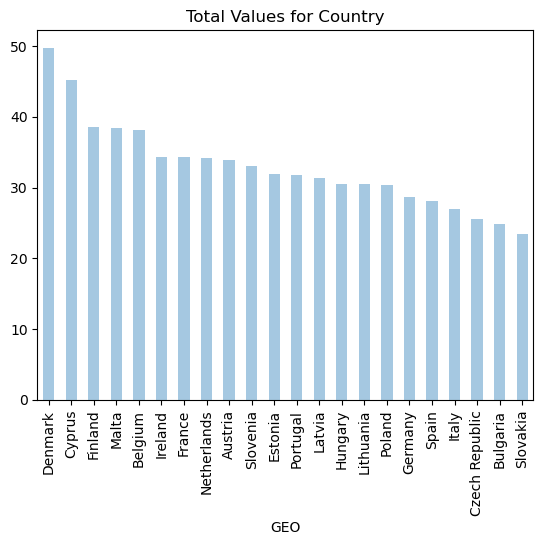

In [76]:
totalSum = pivedu.sum(axis = 1).sort_values(ascending = False)
totalSum.plot(kind = 'bar', style = 'b', alpha = 0.4, title = 'Total Values for Country')

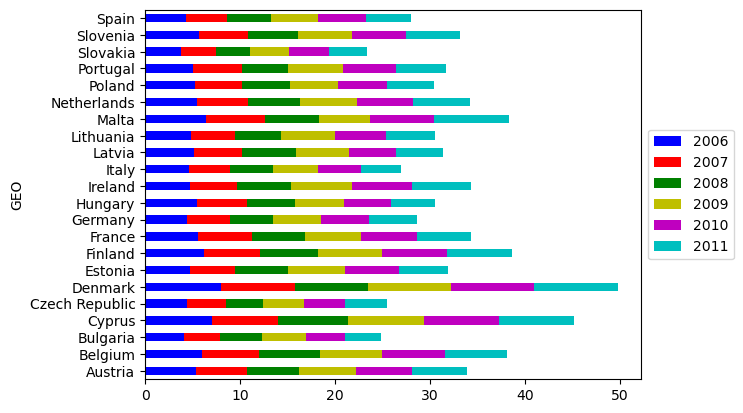

In [77]:
my_colors = ['b', 'r', 'g', 'y', 'm', 'c']
ax = pivedu.plot(kind = 'barh',
                 stacked = True,
                 color = my_colors)
ax.legend(loc = 'center left', bbox_to_anchor = (1, .5))

#### The number of default colors in a plot is only 5, thus if you have more than 5 Series to show, you need to specify more colors or otherwise the same set of colors will be used again. 
#### We can set a new set of colors using the keyword color with a list of colors. Basic colors have a single-character code assigned to each, for example, “b” is for blue, “r” for red, “g” for green, “y” for yellow, “m” for magenta, and “c” for cyan. 
#### When several Series are shown in a plot, a legend is created for identifying each one. The name for each Series is the name of the column in the DataFrame. By default, the legend goes inside the plot area. If we want to change this, we can use the legend function of the axis object (this is the object returned when the plot function is called).
#### By using the loc keyword, we can set the relative position of the legend with respect to the plot. It can be a combination of right or left and upper, lower, or center. With bbox_to_anchor we can set an absolute position with respect to the plot, allowing us to put the legend outside the graph.